In [9]:
# 1) Setup & Imports
import os
import re
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
PREPROCESSED_DIR = Path(r"C:\Users\buck\Napplee\StressClassification\data\preprocessed")
FEATURE_DIR = Path(r"C:\Users\buck\Napplee\StressClassification\data\features")
FEATURE_FILE = FEATURE_DIR / "features_hrv.csv"
ARTIFACTS_DIR = Path("artifacts")
REPORTS_DIR = Path("reports")

for p in [FEATURE_DIR, ARTIFACTS_DIR, REPORTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"Preprocessed directory: {PREPROCESSED_DIR}")
print(f"Feature file output: {FEATURE_FILE}")
print(f"Artifacts directory: {ARTIFACTS_DIR.resolve()}")

Preprocessed directory: C:\Users\buck\Napplee\StressClassification\data\preprocessed
Feature file output: C:\Users\buck\Napplee\StressClassification\data\features\features_hrv.csv
Artifacts directory: C:\Users\buck\Napplee\StressClassification\artifacts


In [10]:
def discover_data_files(data_dir: Path):
    patterns = ["*.csv", "*.xlsx", "*.xls", "*.json"]
    files = []
    for pattern in patterns:
        files.extend(data_dir.rglob(pattern))
    return sorted([p for p in files if p.is_file()])


def load_single_file(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    if suffix == ".json":
        return pd.read_json(path)
    raise ValueError(f"Unsupported file format: {path}")


if not PREPROCESSED_DIR.exists():
    raise FileNotFoundError(
        f"Khong tim thay thu muc preprocessed: {PREPROCESSED_DIR}. Vui long kiem tra lai duong dan."
    )

raw_files_all = discover_data_files(PREPROCESSED_DIR)
npy_files = sorted(PREPROCESSED_DIR.rglob("*.npy"))

# Loai bo file metadata thong ke de tranh doc nham vao raw dataframe
metadata_names = {"preprocessing_stats.json"}
raw_files = [p for p in raw_files_all if p.name.lower() not in metadata_names]
skipped_metadata = [p for p in raw_files_all if p.name.lower() in metadata_names]

print(f"Tong so file tabular tim thay trong preprocessed: {len(raw_files)}")
print(f"Tong so file npy tim thay trong preprocessed: {len(npy_files)}")
if skipped_metadata:
    print("Bo qua file metadata:", [str(p.name) for p in skipped_metadata])

frames = []
failed_files = []
skipped_non_tabular = []

for fpath in raw_files:
    try:
        df_i = load_single_file(fpath)
        if df_i is None or df_i.empty:
            continue

        df_i = df_i.copy()
        if "source_file" not in df_i.columns:
            df_i["source_file"] = str(fpath.relative_to(PREPROCESSED_DIR))

        # Chi giu file co cot lien quan den waveform/feature train
        accepted_markers = {"Time", "Voltage", "Peak", "label", "Label", "stress", "target", "class"}
        if len(set(df_i.columns).intersection(accepted_markers)) == 0:
            skipped_non_tabular.append(str(fpath))
            continue

        frames.append(df_i)
    except Exception as ex:
        failed_files.append((str(fpath), str(ex)))

raw_df = pd.concat(frames, axis=0, ignore_index=True) if frames else pd.DataFrame()
print("\n=== Raw Data Summary ===")
print(f"Shape: {raw_df.shape}")
if not raw_df.empty:
    print(f"Columns: {raw_df.columns.tolist()}")
    print("\nDtypes:")
    print(raw_df.dtypes)
    print("\nTop missing values:")
    print(raw_df.isna().sum().sort_values(ascending=False).head(20))
else:
    print("Khong co bang du lieu tabular hop le trong preprocessed sau khi loc metadata.")

if skipped_non_tabular:
    print("\nBo qua file khong phai waveform/feature table:")
    for fp in skipped_non_tabular[:10]:
        print(f"- {fp}")

if failed_files:
    print("\nCanh bao: mot so file khong doc duoc:")
    for fp, err in failed_files[:10]:
        print(f"- {fp}: {err}")

raw_df.head() if not raw_df.empty else pd.DataFrame()

Tong so file tabular tim thay trong preprocessed: 0
Tong so file npy tim thay trong preprocessed: 6
Bo qua file metadata: ['preprocessing_stats.json']

=== Raw Data Summary ===
Shape: (0, 0)
Khong co bang du lieu tabular hop le trong preprocessed sau khi loc metadata.


""


In [11]:
REQUIRED_COLS = ["Time", "Voltage", "Peak", "source_file"]
LABEL_CANDIDATES = ["label", "Label", "stress", "stress_level", "target", "class"]
WINDOW_SEC = 30.0
MIN_RR_COUNT = 3


def find_label_column(df_in: pd.DataFrame):
    for c in LABEL_CANDIDATES:
        if c in df_in.columns:
            return c
    return None


def load_feature_candidates() -> pd.DataFrame:
    data_root = PREPROCESSED_DIR.parent
    candidates = [
        FEATURE_FILE,
        data_root / "hrv_features_label.csv",
        data_root / "hrv_features.csv",
    ]

    for fp in candidates:
        if fp.exists() and fp.is_file():
            try:
                tmp = pd.read_csv(fp)
                if not tmp.empty:
                    print(f"Fallback: su dung feature file co san -> {fp}")
                    return tmp.copy()
            except Exception as ex:
                print(f"Khong doc duoc {fp}: {ex}")

    return pd.DataFrame()


def standardize_features_df(df_in: pd.DataFrame) -> pd.DataFrame:
    out = df_in.copy()
    out = out.loc[:, ~out.columns.astype(str).str.startswith("Unnamed:")].copy()

    label_col = find_label_column(out)
    if label_col is None:
        raise ValueError(
            "Khong tim thay cot label trong feature dataset. Can mot trong cac cot: "
            + ", ".join(LABEL_CANDIDATES)
        )

    if label_col != "label":
        out = out.rename(columns={label_col: "label"})

    out = out.dropna(subset=["label"]).copy()
    if out.empty:
        raise ValueError("Feature dataset rong sau khi loai bo dong thieu label.")

    if "source_file" not in out.columns:
        out["source_file"] = "precomputed_features"
    if "window_id" not in out.columns:
        out["window_id"] = np.arange(len(out))

    if out["label"].dtype == "O" or str(out["label"].dtype).startswith("category"):
        out["label"] = out["label"].astype(str).str.strip()
    else:
        out["label"] = pd.to_numeric(out["label"], errors="coerce")

    out = out.dropna(subset=["label"]).copy()
    if out.empty:
        raise ValueError("Khong con mau nao sau khi chuan hoa cot label.")

    return out


def load_from_preprocessed_npy(preprocessed_dir: Path) -> pd.DataFrame:
    split_pairs = [("train", "X_train.npy", "y_train.npy"), ("val", "X_val.npy", "y_val.npy"), ("test", "X_test.npy", "y_test.npy")]
    parts = []

    for split_name, x_name, y_name in split_pairs:
        x_path = preprocessed_dir / x_name
        y_path = preprocessed_dir / y_name
        if not (x_path.exists() and y_path.exists()):
            continue

        X_split = np.load(x_path, allow_pickle=True)
        y_split = np.load(y_path, allow_pickle=True)

        if len(X_split.shape) > 2:
            X_split = X_split.reshape(X_split.shape[0], -1)
        if len(y_split.shape) > 1:
            y_split = y_split.reshape(-1)

        if len(X_split) != len(y_split):
            raise ValueError(f"Kich thuoc X/y khong khop o split {split_name}: {len(X_split)} vs {len(y_split)}")

        col_names = [f"feat_{i:04d}" for i in range(X_split.shape[1])]
        df_split = pd.DataFrame(X_split, columns=col_names)
        df_split["label"] = y_split
        df_split["source_file"] = f"preprocessed_{split_name}"
        df_split["window_id"] = np.arange(len(df_split))
        parts.append(df_split)

    if not parts:
        return pd.DataFrame()

    return pd.concat(parts, axis=0, ignore_index=True)


# Mode 1: raw waveform trong preprocessed
if set(REQUIRED_COLS).issubset(set(raw_df.columns)):
    print("Da tim thay du lieu raw waveform trong preprocessed -> trich xuat feature HRV.")
    df = raw_df.copy()
    for c in ["Time", "Voltage", "Peak"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["Time", "Voltage", "Peak", "source_file"]).copy()

    if df.empty:
        raise ValueError("Du lieu raw rong sau khi lam sach cot Time/Voltage/Peak/source_file.")

    def infer_label(group_df: pd.DataFrame, source_name: str):
        for col in LABEL_CANDIDATES:
            if col in group_df.columns and group_df[col].notna().any():
                v = group_df[col].dropna().mode().iloc[0]
                try:
                    return int(float(v))
                except Exception:
                    return str(v)

        src = str(source_name).lower()
        patterns = [r"(?:pure|mixed)[_/](\d)", r"(?:pure|mixed)_(\d)", r"[/_](\d)(?:[/_]|$)"]
        for p in patterns:
            m = re.search(p, src)
            if m:
                return int(m.group(1))
        return np.nan

    def safe_skew(x: np.ndarray) -> float:
        return float(pd.Series(x).skew()) if len(x) >= 3 else np.nan

    def safe_kurt(x: np.ndarray) -> float:
        return float(pd.Series(x).kurt()) if len(x) >= 4 else np.nan

    def rr_frequency_features(rr_ms: np.ndarray):
        if len(rr_ms) < 4:
            return np.nan, np.nan, np.nan, np.nan
        rr_s = rr_ms / 1000.0
        t = np.cumsum(rr_s) - rr_s[0]
        if t[-1] <= 0:
            return np.nan, np.nan, np.nan, np.nan
        fs = 4.0
        t_uniform = np.arange(0, t[-1], 1 / fs)
        if len(t_uniform) < 8:
            return np.nan, np.nan, np.nan, np.nan

        rr_interp = np.interp(t_uniform, t, rr_ms)
        rr_detrended = rr_interp - np.nanmean(rr_interp)
        fft_vals = np.fft.rfft(rr_detrended)
        freqs = np.fft.rfftfreq(len(rr_detrended), d=1 / fs)
        psd = (np.abs(fft_vals) ** 2) / max(len(rr_detrended), 1)

        lf_mask = (freqs >= 0.04) & (freqs < 0.15)
        hf_mask = (freqs >= 0.15) & (freqs <= 0.40)
        total_mask = (freqs >= 0.04) & (freqs <= 0.40)

        lf_power = float(np.trapz(psd[lf_mask], freqs[lf_mask])) if np.any(lf_mask) else np.nan
        hf_power = float(np.trapz(psd[hf_mask], freqs[hf_mask])) if np.any(hf_mask) else np.nan
        total_power = float(np.trapz(psd[total_mask], freqs[total_mask])) if np.any(total_mask) else np.nan
        lf_hf_ratio = (lf_power / hf_power) if (pd.notna(lf_power) and pd.notna(hf_power) and hf_power > 0) else np.nan
        return lf_power, hf_power, lf_hf_ratio, total_power

    def extract_features_from_group(g: pd.DataFrame, source_name: str, window_id=np.nan):
        g = g.sort_values("Time")
        peak_times = g.loc[g["Peak"] > 0, "Time"].values
        if len(peak_times) < 4:
            return None, "too_few_peaks"
        rr_ms = np.diff(peak_times) * 1000.0
        rr_ms = rr_ms[(rr_ms >= 300.0) & (rr_ms <= 2000.0)]
        if len(rr_ms) < MIN_RR_COUNT:
            return None, "too_few_rr_after_filter"

        rmssd = np.sqrt(np.mean(np.diff(rr_ms) ** 2)) if len(rr_ms) >= 2 else np.nan
        pnn50 = float(np.mean(np.abs(np.diff(rr_ms)) > 50.0) * 100.0) if len(rr_ms) >= 2 else np.nan
        mean_rr_ms = float(np.mean(rr_ms))
        hr_bpm = 60000.0 / mean_rr_ms if mean_rr_ms > 0 else np.nan
        duration_sec = float(g["Time"].max() - g["Time"].min())
        n_peaks = int(np.sum(g["Peak"] > 0))
        peak_rate = n_peaks / duration_sec if duration_sec > 0 else np.nan
        lf_power, hf_power, lf_hf_ratio, total_power = rr_frequency_features(rr_ms)

        row = {
            "source_file": source_name,
            "window_id": window_id,
            "label": infer_label(g, source_name),
            "mean_rr_ms": mean_rr_ms,
            "median_rr_ms": float(np.median(rr_ms)),
            "std_rr_ms": float(np.std(rr_ms, ddof=1)) if len(rr_ms) > 1 else np.nan,
            "rmssd_ms": float(rmssd),
            "pnn50": float(pnn50),
            "heart_rate_bpm": float(hr_bpm),
            "n_peaks": n_peaks,
            "duration_sec": duration_sec,
            "peak_rate_per_sec": float(peak_rate),
            "voltage_mean": float(g["Voltage"].mean()),
            "voltage_std": float(g["Voltage"].std(ddof=1)) if len(g) > 1 else np.nan,
            "voltage_min": float(g["Voltage"].min()),
            "voltage_max": float(g["Voltage"].max()),
            "voltage_skew": safe_skew(g["Voltage"].values),
            "voltage_kurtosis": safe_kurt(g["Voltage"].values),
            "lf_power": lf_power,
            "hf_power": hf_power,
            "lf_hf_ratio": lf_hf_ratio,
            "total_power": total_power,
        }
        return row, None

    base_groups = list(df.groupby(["source_file"], sort=False))
    feature_rows = []
    skip_log = {"too_few_peaks": 0, "too_few_rr_after_filter": 0}

    for key, g in base_groups:
        source_name = str(key)
        duration = float(g["Time"].max() - g["Time"].min())
        if duration > WINDOW_SEC * 1.5:
            g2 = g.copy()
            g2["_window"] = ((g2["Time"] - g2["Time"].min()) // WINDOW_SEC).astype(int)
            for wv, gw in g2.groupby("_window", sort=False):
                row, reason = extract_features_from_group(gw, source_name, window_id=int(wv))
                if row is not None:
                    feature_rows.append(row)
                else:
                    skip_log[reason] = skip_log.get(reason, 0) + 1
            continue

        row, reason = extract_features_from_group(g, source_name)
        if row is not None:
            feature_rows.append(row)
        else:
            skip_log[reason] = skip_log.get(reason, 0) + 1

    features_df = pd.DataFrame(feature_rows)
    if features_df.empty:
        raise ValueError("Khong trich xuat duoc feature tu raw waveform.")

    print("Skip log:", skip_log)
    features_df = features_df.dropna(subset=["label"]).copy()

# Mode 2: preprocessed npy splits
elif all((PREPROCESSED_DIR / f).exists() for f in ["X_train.npy", "y_train.npy", "X_test.npy", "y_test.npy"]):
    print(
        "Canh bao: thieu cot raw waveform (Time, Voltage, Peak). "
        "Dang train truc tiep tu X_*.npy va y_*.npy trong preprocessed."
    )
    features_df = load_from_preprocessed_npy(PREPROCESSED_DIR)
    if features_df.empty:
        raise ValueError("Khong tao duoc feature dataframe tu npy splits.")

# Mode 3: fallback feature table
else:
    print(
        "Canh bao: khong co raw waveform va cung khong du npy splits. "
        "Chuyen sang su dung feature file co san."
    )
    fallback_df = load_feature_candidates()
    if fallback_df.empty:
        raise ValueError(
            "Khong tim thay du lieu de train. Can it nhat mot trong 3 mode: "
            "(1) raw waveform co Time/Voltage/Peak, (2) X_*.npy + y_*.npy, (3) feature csv co cot label."
        )
    features_df = fallback_df.copy()

features_df = standardize_features_df(features_df)
features_df.to_csv(FEATURE_FILE, index=False)
print(f"\nSaved features file: {FEATURE_FILE}")
print(f"Feature shape: {features_df.shape}")
print("\nClass distribution (label):")
print(features_df["label"].value_counts(dropna=False).sort_index())
display(features_df.head())

Canh bao: thieu cot raw waveform (Time, Voltage, Peak). Dang train truc tiep tu X_*.npy va y_*.npy trong preprocessed.

Saved features file: C:\Users\buck\Napplee\StressClassification\data\features\features_hrv.csv
Feature shape: (266574, 515)

Class distribution (label):
label
0    70494
1    94841
2    70482
3    30757
Name: count, dtype: int64


,feat_0000,feat_0001,feat_0002,feat_0003,feat_0004,feat_0005,feat_0006,feat_0007,feat_0008,feat_0009,...,feat_0505,feat_0506,feat_0507,feat_0508,feat_0509,feat_0510,feat_0511,label,source_file,window_id
0,0.222107,0.224669,0.241321,0.247815,0.195209,0.259601,0.142239,0.175784,0.216140,0.130966,...,0.478231,0.529564,0.503909,0.482272,0.467541,0.513613,0.553988,1,preprocessed_train,0
1,0.241075,0.321771,0.342764,0.277368,0.250531,0.339144,0.341315,0.296880,0.309900,0.247098,...,0.408703,0.367005,0.305104,0.315271,0.290445,0.284428,0.359735,2,preprocessed_train,1
2,0.456594,0.397171,0.440678,0.372017,0.414562,0.421003,0.389364,0.382525,0.383987,0.332578,...,0.509664,0.469343,0.478456,0.532980,0.457551,0.461257,0.514325,0,preprocessed_train,2
3,0.276037,0.255362,0.253215,0.354904,0.351506,0.348043,0.400166,0.332978,0.409898,0.408275,...,0.515772,0.487885,0.540420,0.512926,0.418710,0.487251,0.450945,0,preprocessed_train,3
4,0.344517,0.384530,0.412911,0.466158,0.404930,0.465392,0.458870,0.497180,0.394039,0.408921,...,0.330184,0.329709,0.292167,0.328471,0.375699,0.332259,0.271181,2,preprocessed_train,4


Feature dataset preview:


,feat_0000,feat_0001,feat_0002,feat_0003,feat_0004,feat_0005,feat_0006,feat_0007,feat_0008,feat_0009,...,feat_0505,feat_0506,feat_0507,feat_0508,feat_0509,feat_0510,feat_0511,label,source_file,window_id
0,0.222107,0.224669,0.241321,0.247815,0.195209,0.259601,0.142239,0.175784,0.216140,0.130966,...,0.478231,0.529564,0.503909,0.482272,0.467541,0.513613,0.553988,1,preprocessed_train,0
1,0.241075,0.321771,0.342764,0.277368,0.250531,0.339144,0.341315,0.296880,0.309900,0.247098,...,0.408703,0.367005,0.305104,0.315271,0.290445,0.284428,0.359735,2,preprocessed_train,1
2,0.456594,0.397171,0.440678,0.372017,0.414562,0.421003,0.389364,0.382525,0.383987,0.332578,...,0.509664,0.469343,0.478456,0.532980,0.457551,0.461257,0.514325,0,preprocessed_train,2
3,0.276037,0.255362,0.253215,0.354904,0.351506,0.348043,0.400166,0.332978,0.409898,0.408275,...,0.515772,0.487885,0.540420,0.512926,0.418710,0.487251,0.450945,0,preprocessed_train,3
4,0.344517,0.384530,0.412911,0.466158,0.404930,0.465392,0.458870,0.497180,0.394039,0.408921,...,0.330184,0.329709,0.292167,0.328471,0.375699,0.332259,0.271181,2,preprocessed_train,4



Describe numeric features:


,count,mean,std,min,25%,50%,75%,max
feat_0000,266574.0,0.390798,0.121105,0.015852,0.310604,0.373365,0.451899,0.992149
feat_0001,266574.0,0.390605,0.120809,0.017119,0.310425,0.373305,0.451600,0.991361
feat_0002,266574.0,0.390549,0.120736,0.002321,0.310562,0.373376,0.451156,0.982077
feat_0003,266574.0,0.390629,0.120669,0.014295,0.310560,0.373576,0.451619,0.975862
feat_0004,266574.0,0.390471,0.120711,0.011869,0.310429,0.373368,0.451239,0.991139
feat_0005,266574.0,0.390437,0.120797,0.007775,0.310474,0.373122,0.451705,0.991992
feat_0006,266574.0,0.390561,0.120819,0.020127,0.310524,0.373295,0.451524,0.989976
feat_0007,266574.0,0.390565,0.120881,0.008981,0.310366,0.373201,0.451569,0.976610
feat_0008,266574.0,0.390770,0.120965,0.008981,0.310500,0.373441,0.451652,0.978853
feat_0009,266574.0,0.390817,0.121005,0.018062,0.310807,0.373391,0.451801,0.980941


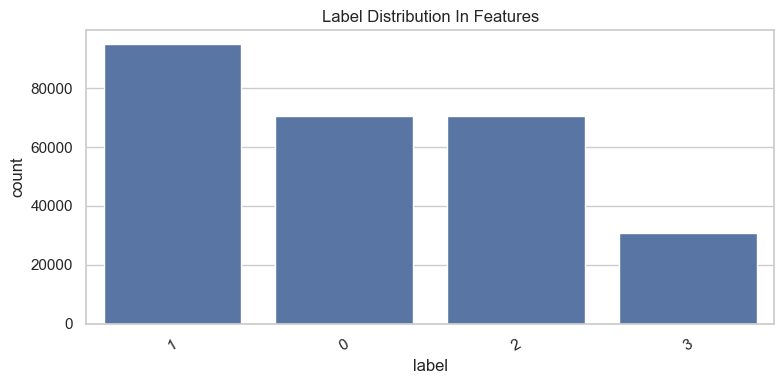

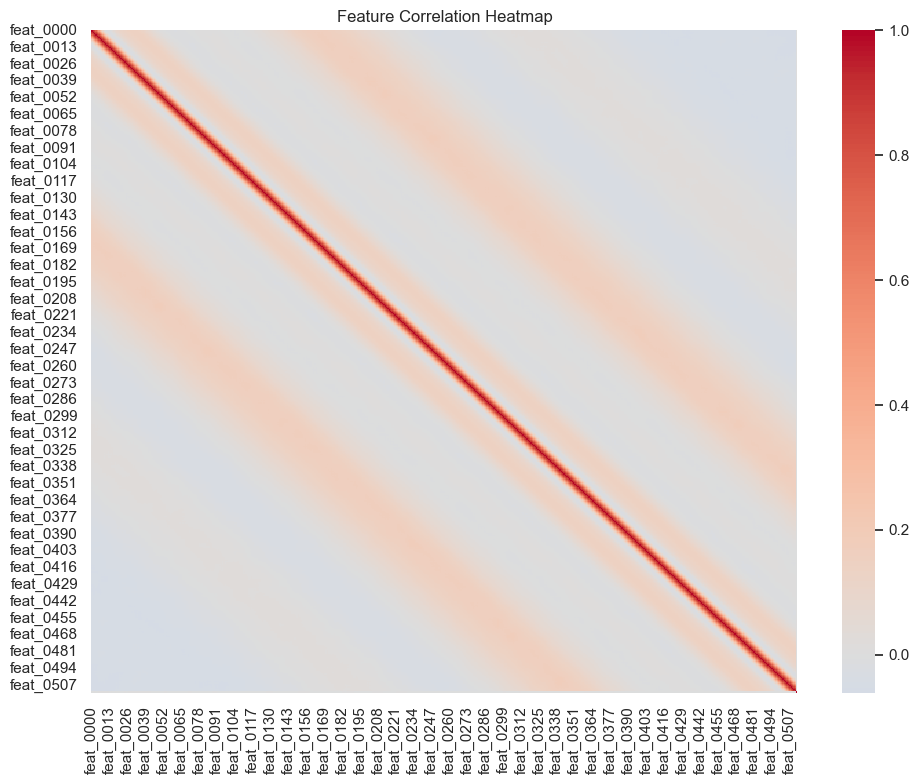

In [12]:
if "label" not in features_df.columns:
    raise ValueError("Khong co cot label trong features_df de train classifier.")

print("Feature dataset preview:")
display(features_df.head())

print("\nDescribe numeric features:")
display(features_df.describe(include=[np.number]).T.head(20))

plt.figure(figsize=(8, 4))
sns.countplot(data=features_df, x="label", order=features_df["label"].value_counts().index)
plt.title("Label Distribution In Features")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

num_cols = [c for c in features_df.select_dtypes(include=[np.number]).columns if c != "label"]
if len(num_cols) >= 2:
    plt.figure(figsize=(10, 8))
    sns.heatmap(features_df[num_cols].corr(numeric_only=True), cmap="coolwarm", center=0)
    plt.title("Feature Correlation Heatmap")
    plt.tight_layout()
    plt.show()

In [13]:
data_model = features_df.copy()

# Cot giu de trace/ID, khong dua vao feature train
leakage_or_trace_cols = [c for c in ["source_file", "window_id"] if c in data_model.columns]

X = data_model.drop(columns=["label"] + leakage_or_trace_cols)
y_raw = data_model["label"]

if y_raw.nunique(dropna=True) < 2:
    raise ValueError("Target label chi co 1 lop, khong the train classifier.")

# Feature engineering nhe cho du lieu waveform da flatten (feat_*)
raw_wave_cols = [c for c in X.columns if str(c).startswith("feat_")]
if raw_wave_cols:
    arr = X[raw_wave_cols].to_numpy(dtype=np.float32)
    row_mean = arr.mean(axis=1)
    row_std = arr.std(axis=1)
    row_min = arr.min(axis=1)
    row_max = arr.max(axis=1)
    row_ptp = row_max - row_min
    row_abs_mean = np.abs(arr).mean(axis=1)
    row_energy = np.square(arr).mean(axis=1)
    q25 = np.quantile(arr, 0.25, axis=1)
    q75 = np.quantile(arr, 0.75, axis=1)
    iqr = q75 - q25
    zc = np.sum(np.diff(np.sign(arr), axis=1) != 0, axis=1)

    X = X.copy()
    X["sig_mean"] = row_mean
    X["sig_std"] = row_std
    X["sig_min"] = row_min
    X["sig_max"] = row_max
    X["sig_ptp"] = row_ptp
    X["sig_abs_mean"] = row_abs_mean
    X["sig_energy"] = row_energy
    X["sig_q25"] = q25
    X["sig_q75"] = q75
    X["sig_iqr"] = iqr
    X["sig_zero_crossings"] = zc
    print(f"Da them {11} feature thong ke tu waveform flatten.")

label_encoder = None
if y_raw.dtype == "O" or str(y_raw.dtype).startswith("category"):
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y_raw.astype(str))
    class_names = label_encoder.classes_.tolist()
    print(f"LabelEncoder applied. Classes: {class_names}")
else:
    y = y_raw.astype(int).values
    class_names = sorted(pd.Series(y).dropna().unique().tolist())

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

if len(numeric_features) + len(categorical_features) == 0:
    raise ValueError("Khong con feature hop le de train sau khi loai leakage columns.")

print(f"Modeling samples: {len(X)}")
print(f"Target classes: {class_names}")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

feature_columns = X.columns.tolist()
print(f"Feature matrix shape: {X.shape}")

Da them 11 feature thong ke tu waveform flatten.
Modeling samples: 266574
Target classes: [0, 1, 2, 3]
Numeric features: 523
Categorical features: 0
Feature matrix shape: (266574, 523)


In [14]:
y_series = pd.Series(y)
n_samples = len(X)

if n_samples < 2:
    raise ValueError(
        "So mau sau buoc feature extraction qua it (<2), khong the split train/test."
    )

if y_series.nunique() < 2:
    raise ValueError(
        "Target chi co 1 lop trong du lieu modeling, khong the train classifier."
    )

class_counts = y_series.value_counts()
can_stratify = class_counts.min() >= 2 and y_series.nunique() > 1 and n_samples >= 4

stratify_arg = y if can_stratify else None
if not can_stratify:
    print("Canh bao: khong the stratify do co lop qua it mau. Se split khong stratify.")

if n_samples == 2:
    test_size = 0.5
elif n_samples == 3:
    test_size = 1 / 3
else:
    test_size = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_size,
    random_state=RANDOM_STATE,
    stratify=stratify_arg,
)

print(f"test_size su dung: {test_size}")
print(f"X_train: {X_train.shape}, y_train: {len(y_train)}")
print(f"X_test:  {X_test.shape}, y_test:  {len(y_test)}")
print("Class distribution in train:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

test_size su dung: 0.2
X_train: (213259, 523), y_train: 213259
X_test:  (53315, 523), y_test:  53315
Class distribution in train:
0    0.264444
1    0.355779
2    0.264397
3    0.115381
Name: proportion, dtype: float64


In [15]:
from sklearn.svm import LinearSVC

def make_pipeline(model):
    return Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])


is_binary = len(np.unique(y_train)) == 2
primary_scoring = "f1" if is_binary else "f1_weighted"

# Chi giu 2 model nhu yeu cau: Logistic Regression + SVM (LinearSVC de train nhanh hon)
models = {
    "LogisticRegression_balanced": make_pipeline(
        LogisticRegression(
            max_iter=3000,
            C=2.0,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    ),
    "LinearSVM_balanced": make_pipeline(
        LinearSVC(
            C=1.0,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            max_iter=5000,
        )
    ),
}

print("Models to train:", list(models.keys()))

Models to train: ['LogisticRegression_balanced', 'LinearSVM_balanced']


In [16]:
import time

def evaluate_model(model_name: str, fitted_model, X_eval, y_eval, is_binary_task: bool):
    y_pred = fitted_model.predict(X_eval)

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision_weighted": precision_score(y_eval, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_eval, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_eval, y_pred, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_eval, y_pred, average="macro", zero_division=0),
    }

    if is_binary_task and hasattr(fitted_model, "predict_proba"):
        y_proba = fitted_model.predict_proba(X_eval)[:, 1]
        result["roc_auc"] = roc_auc_score(y_eval, y_proba)
    else:
        result["roc_auc"] = np.nan

    print(f"\n===== {model_name} =====")
    print("Confusion Matrix:")
    print(confusion_matrix(y_eval, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_eval, y_pred, zero_division=0))

    return result


results = []
fitted_models = {}
failed_models = []

for model_name, pipe in models.items():
    try:
        t0 = time.time()
        pipe.fit(X_train, y_train)
        train_sec = time.time() - t0

        fitted_models[model_name] = pipe
        metrics = evaluate_model(model_name, pipe, X_test, y_test, is_binary)
        metrics["train_seconds"] = round(train_sec, 2)
        results.append(metrics)
    except KeyboardInterrupt:
        print(f"\nBo qua model {model_name} do bi ngat trong qua trinh train.")
        failed_models.append((model_name, "KeyboardInterrupt"))
    except Exception as ex:
        print(f"\nModel {model_name} loi: {ex}")
        failed_models.append((model_name, str(ex)))

if not results:
    raise ValueError("Tat ca model deu that bai khi train. Kiem tra lai cau hinh model va du lieu.")

results_df = pd.DataFrame(results).sort_values("f1_weighted", ascending=False).reset_index(drop=True)
print("\n=== Model Comparison (sorted by f1_weighted) ===")
display(results_df)

if failed_models:
    print("\nModels bi bo qua/that bai:")
    for name, reason in failed_models:
        print(f"- {name}: {reason}")

best_model_name = results_df.loc[0, "model"]
best_model = fitted_models[best_model_name]
print(f"Best model hien tai: {best_model_name}")

if is_binary:
    plt.figure(figsize=(7, 5))
    for model_name, fitted_model in fitted_models.items():
        if hasattr(fitted_model, "predict_proba"):
            y_proba = fitted_model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            plt.plot(fpr, tpr, label=model_name)

    plt.plot([0, 1], [0, 1], "k--", alpha=0.7)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves (Binary Classification)")
    plt.legend()
    plt.tight_layout()
    plt.show()


===== LogisticRegression_balanced =====
Confusion Matrix:
[[7940 2218 1709 2232]
 [6812 3240 3329 5587]
 [3374 2264 2798 5661]
 [ 961  834 1108 3248]]

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.56      0.48     14099
           1       0.38      0.17      0.24     18968
           2       0.31      0.20      0.24     14097
           3       0.19      0.53      0.28      6151

    accuracy                           0.32     53315
   macro avg       0.33      0.37      0.31     53315
weighted avg       0.35      0.32      0.31     53315


===== LinearSVM_balanced =====
Confusion Matrix:
[[7971 3110 1994 1024]
 [6820 4788 4528 2832]
 [3392 3496 4112 3097]
 [ 963 1355 1893 1940]]

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.57      0.48     14099
           1       0.38      0.25      0.30     18968
           2       0.33      0.29      0.31     14097
     

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro,roc_auc,train_seconds
0,LinearSVM_balanced,0.352828,0.355671,0.352828,0.345655,0.337064,NaN,303.33
1,LogisticRegression_balanced,0.323099,0.349850,0.323099,0.307276,0.310186,NaN,68.55


Best model hien tai: LinearSVM_balanced
